### Importing libraries

In [27]:
#Importing libraries
import pyarrow.parquet as pq
import polars as pl
import os
import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
import xgboost as xgb
import shap
from sklearn.model_selection import GridSearchCV
import pandas as pd
from imblearn.over_sampling import SMOTE

### Loading dataset into memory through Polars

In [28]:
#Carregando dados na memória
default_path = "C:/Users/Italo/Desktop/UERJ/2026.1/cibersecurity/cybersecurity-uerj-2026-1"
parquet_path = os.path.join(default_path, "final-project/db/dnn.parquet")
print(parquet_path)
tabela_arrow = pq.read_table(parquet_path)
df = pl.from_arrow(tabela_arrow)

C:/Users/Italo/Desktop/UERJ/2026.1/cibersecurity/cybersecurity-uerj-2026-1\final-project/db/dnn.parquet


#### Checking columns types

In [29]:
schema_dict = df.schema

# 3. Print the results nicely
print("--- Generated Columns and Data Types ---")
for col_name, dtype in schema_dict.items():
    print(f"Column: {col_name:<15} | Type: {dtype}")

--- Generated Columns and Data Types ---
Column: frame.time      | Type: String
Column: ip.src_host     | Type: String
Column: ip.dst_host     | Type: String
Column: arp.dst.proto_ipv4 | Type: String
Column: arp.opcode      | Type: Float64
Column: arp.hw.size     | Type: Float64
Column: arp.src.proto_ipv4 | Type: String
Column: icmp.checksum   | Type: Float64
Column: icmp.seq_le     | Type: Float64
Column: icmp.transmit_timestamp | Type: Float64
Column: icmp.unused     | Type: Float64
Column: http.file_data  | Type: String
Column: http.content_length | Type: Float64
Column: http.request.uri.query | Type: String
Column: http.request.method | Type: String
Column: http.referer    | Type: String
Column: http.request.full_uri | Type: String
Column: http.request.version | Type: String
Column: http.response   | Type: Float64
Column: http.tls_port   | Type: Float64
Column: tcp.ack         | Type: Float64
Column: tcp.ack_raw     | Type: Float64
Column: tcp.checksum    | Type: Float64
Column: tc

### Pre processing data

#### Droping unnecessary columns

In [30]:


#Essas são colunnas de texto. Amanhã, traduzir estas colunas de texto para o 
# formato float trazendo o len() do valor da coluna com o objetivo de possibilitar o treino via XGBoost
drop_columns = [
    'frame.time',
    'ip.src_host',
    'ip.dst_host',
    'arp.src.proto_ipv4',
    'arp.dst.proto_ipv4',
    'tcp.options',
    'mqtt.conack.flags',
    'mqtt.msg',
    'mqtt.topic'
    ]
df = df.drop(drop_columns)
df.head(20)


arp.opcode,arp.hw.size,icmp.checksum,icmp.seq_le,icmp.transmit_timestamp,icmp.unused,http.file_data,http.content_length,http.request.uri.query,http.request.method,http.referer,http.request.full_uri,http.request.version,http.response,http.tls_port,tcp.ack,tcp.ack_raw,tcp.checksum,tcp.connection.fin,tcp.connection.rst,tcp.connection.syn,tcp.connection.synack,tcp.dstport,tcp.flags,tcp.flags.ack,tcp.len,tcp.payload,tcp.seq,tcp.srcport,udp.port,udp.stream,udp.time_delta,dns.qry.name,dns.qry.name.len,dns.qry.qu,dns.qry.type,dns.retransmission,dns.retransmit_request,dns.retransmit_request_in,mqtt.conflag.cleansess,mqtt.conflags,mqtt.hdrflags,mqtt.len,mqtt.msg_decoded_as,mqtt.msgtype,mqtt.proto_len,mqtt.protoname,mqtt.topic_len,mqtt.ver,mbtcp.len,mbtcp.trans_id,mbtcp.unit_id,Attack_label,Attack_type
f64,f64,f64,f64,f64,f64,str,f64,str,str,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,str,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,i64,str
0.0,0.0,0.0,0.0,0.0,0.0,"""0.0""",0.0,"""0.0""","""0.0""","""0.0""","""0.0""","""0.0""",0.0,0.0,1.0,3.1533e9,47892.0,0.0,0.0,0.0,1.0,64855.0,18.0,1.0,0.0,"""0""",0.0,"""1883.0""",0.0,0.0,0.0,0.0,"""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""0""",0.0,0.0,0.0,0.0,0.0,0,"""Normal"""
0.0,0.0,0.0,0.0,0.0,0.0,"""0.0""",0.0,"""0.0""","""0.0""","""0.0""","""0.0""","""0.0""",0.0,0.0,1.0,3.44794516e8,16077.0,0.0,0.0,0.0,0.0,1883.0,24.0,1.0,14.0,"""100c00044d5154540402003c0000""",1.0,"""64855.0""",0.0,0.0,0.0,0.0,"""0""",0.0,0.0,0.0,0.0,0.0,1.0,2.0,16.0,12.0,0.0,1.0,4.0,"""MQTT""",0.0,4.0,0.0,0.0,0.0,0,"""Normal"""
0.0,0.0,0.0,0.0,0.0,0.0,"""0.0""",0.0,"""0.0""","""0.0""","""0.0""","""0.0""","""0.0""",0.0,0.0,15.0,3.1533e9,62675.0,0.0,0.0,0.0,0.0,64855.0,16.0,1.0,0.0,"""0""",1.0,"""1883.0""",0.0,0.0,0.0,0.0,"""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""0""",0.0,0.0,0.0,0.0,0.0,0,"""Normal"""
0.0,0.0,0.0,0.0,0.0,0.0,"""0.0""",0.0,"""0.0""","""0.0""","""0.0""","""0.0""","""0.0""",0.0,0.0,15.0,3.1533e9,54469.0,0.0,0.0,0.0,0.0,64855.0,24.0,1.0,4.0,"""20020000""",1.0,"""1883.0""",0.0,0.0,0.0,0.0,"""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,32.0,2.0,0.0,2.0,0.0,"""0""",0.0,0.0,0.0,0.0,0.0,0,"""Normal"""
0.0,0.0,0.0,0.0,0.0,0.0,"""0.0""",0.0,"""0.0""","""0.0""","""0.0""","""0.0""","""0.0""",0.0,0.0,5.0,3.4479452e8,53812.0,0.0,0.0,0.0,0.0,1883.0,24.0,1.0,41.0,"""3027001854656d7065726174757265…",15.0,"""64855.0""",0.0,0.0,0.0,0.0,"""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,48.0,39.0,0.0,3.0,0.0,"""0""",24.0,0.0,0.0,0.0,0.0,0,"""Normal"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0.0,0.0,0.0,0.0,0.0,0.0,"""0.0""",0.0,"""0.0""","""0.0""","""0.0""","""0.0""","""0.0""",0.0,0.0,6.0,3.44794521e8,62615.0,0.0,0.0,0.0,0.0,1883.0,16.0,1.0,0.0,"""0""",59.0,"""64855.0""",0.0,0.0,0.0,0.0,"""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""0""",0.0,0.0,0.0,0.0,0.0,0,"""Normal"""
0.0,0.0,0.0,0.0,0.0,0.0,"""0.0""",0.0,"""0.0""","""0.0""","""0.0""","""0.0""","""0.0""",0.0,0.0,1.0,1.0455e9,35755.0,0.0,0.0,0.0,0.0,1883.0,16.0,1.0,0.0,"""0""",1.0,"""64856.0""",0.0,0.0,0.0,0.0,"""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""0""",0.0,0.0,0.0,0.0,0.0,0,"""Normal"""
0.0,0.0,0.0,0.0,0.0,0.0,"""0.0""",0.0,"""0.0""","""0.0""","""0.0""","""0.0""","""0.0""",0.0,0.0,15.0,3.2943e9,35748.0,0.0,0.0,0.0,0.0,64856.0,16.0,1.0,0.0,"""0""",5.0,"""1883.0""",0.0,0.0,0.0,0.0,"""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""0""",0.0,0.0,0.0,0.0,0.0,0,"""Normal"""


#### Measuring amount of attacks

In [31]:

df \
.group_by("http.file_data") \
.agg(pl.len().alias("Quantidade")) \
.with_columns(((pl.col("Quantidade") / pl.sum("Quantidade")) * 100).round(2).alias("%")) \
.sort("Quantidade", descending=True) \
.show(20)


df.filter(pl.col("Attack_label") == 0) \
  .group_by("http.file_data", "Attack_label") \
  .agg(pl.len().alias("Quantidade")).show(50)


http.file_data,Quantidade,%
str,u32,f64
"""0.0""",2053112,92.52
"""0""",121692,5.48
"""<!DOCTYPE HTML PUBLIC ""-//IETF…",20693,0.93
"""method=open+service%3a3%2e0%2e…",8818,0.4
"""<!--#include virtual=""/index.j…",5999,0.27
"""dir=/""",1041,0.05
"""dump_sql=foo""",838,0.04
"""my_post_key=&keywords='+or+'a'…",631,0.03
"""username=admin&password=0&Logi…",552,0.02


http.file_data,Attack_label,Quantidade
str,i64,u32
"""0.0""",0,1615643


#### Converting http.file.data

In [32]:
df = df.with_columns(
    pl.when(pl.col("http.file_data").is_in(["0.0", "0"]))
    .then(0.0)
    .otherwise(pl.col("http.file_data").str.len_bytes().cast(pl.Float64))
    .alias("http.file_data")
)


#### Converting http.request.uri.query

In [33]:
df = df.with_columns(
    pl.when(pl.col("http.request.uri.query").is_in(["0.0", "0"]))
    .then(0.0)
    .otherwise(pl.col("http.request.uri.query").str.len_bytes().cast(pl.Float64))
    .alias("http.request.uri.query")
)

#### Converting http.referer

In [34]:
df = df.with_columns(
    pl.when(pl.col("http.referer").is_in(["0.0", "0"]))
    .then(0.0)
    .otherwise(pl.col("http.referer").str.len_bytes().cast(pl.Float64))
    .alias("http.referer")
)

#### Converting http.request.full_uri

In [35]:
df = df.with_columns(
    pl.when(pl.col("http.request.full_uri").is_in(["0.0", "0"]))
    .then(0.0)
    .otherwise(pl.col("http.request.full_uri").str.len_bytes().cast(pl.Float64))
    .alias("http.request.full_uri")
)

#### Converting http.request.version

In [36]:
df = df.with_columns(
    pl.when(pl.col("http.request.version").is_in(["0.0", "0"]))
    .then(0.0)
    .otherwise(pl.col("http.request.version").str.len_bytes().cast(pl.Float64))
    .alias("http.request.version")
)

#### Converting tcp.srcport

In [37]:

df = df.with_columns(
    pl.col("tcp.srcport").cast(pl.Float64, strict=False).alias("tcp.srcport")
)



#### Converting dns.qry.name.len

In [38]:

df = df.with_columns(
    pl.when(pl.col("dns.qry.name.len").is_in(["0.0", "0"]))
    .then(0.0)
    .when(pl.col("dns.qry.name.len").is_in(["1.0", "1"]))
    .then(1.0)
    .otherwise(pl.col("dns.qry.name.len").str.len_bytes().cast(pl.Float64))
    .alias("dns.qry.name.len")
)


#### Converting mqtt.protoname

In [39]:
df = df.with_columns(
    pl.when(pl.col("mqtt.protoname").is_in(["0.0", "0"]))
    .then(0.0)
    .otherwise(1.0)
    .alias("mqtt.protoname")
)

#### Mapping labels to integers (column "http.request.method")

In [40]:
mapping_rm = {"0.0": 0.0,
                  "0": 0.0,
                  "GET": 1.0,
                  "POST": 2.0,
                  "TRACE": 3.0,
                  "OPTIONS": 4.0,
                  "PROPFIND": 5.0,
                  "PUT": 6.0,
                  "SEARCH": 7.0}

keys = pl.Series(mapping_rm.keys())
values = pl.Series(mapping_rm.values())

df = df.with_columns(
    pl.col("http.request.method").replace_strict(keys, values, default=0)
)

#### Translating labels to float (column "tcp.payload")

In [41]:

#Colocar o tamanho do payload neste aqui 

df = df.with_columns(
    pl.when(pl.col("tcp.payload") != "0")
      .then(pl.lit(0))
      .otherwise(pl.lit(1))
      .cast(pl.Float64)
      .alias("tcp.payload")
)


### Running XGBoost algorithm (binary classification)


[INFO] Modelo XGBoost treinado com sucesso utilizando Polars!

Acurácia Geral: 99.82%

Relatório de Classificação Detalhado:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    484693
           1       1.00      0.99      1.00    181068

    accuracy                           1.00    665761
   macro avg       1.00      1.00      1.00    665761
weighted avg       1.00      1.00      1.00    665761



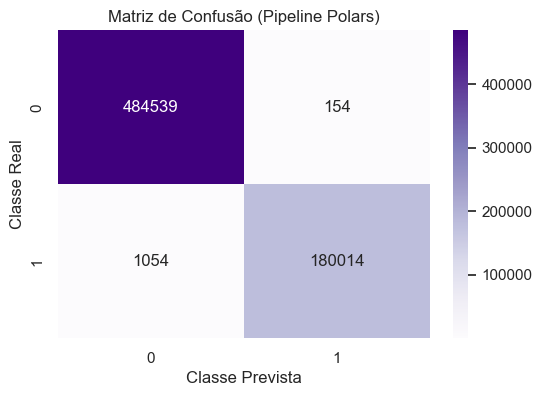

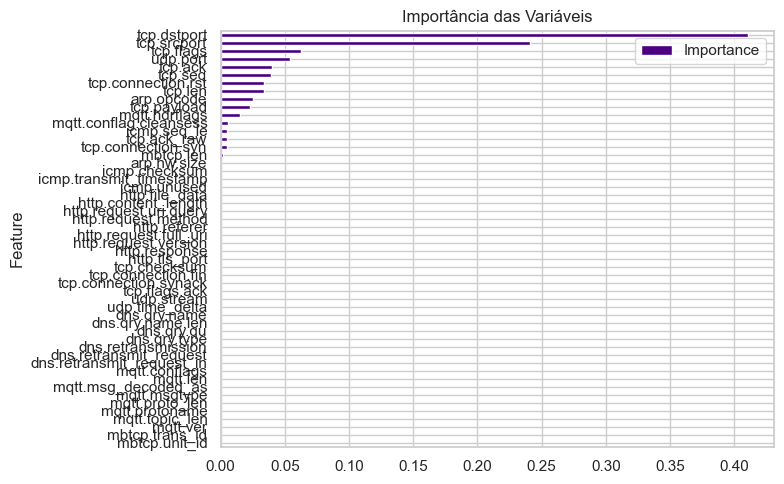

In [43]:
# Criando o DataFrame principal no Polars
X_pl = df.drop("Attack_label", "Attack_type")
y_pl = pl.Series("target", df["Attack_label"])


X_train, X_test, y_train, y_test = train_test_split(
    X_pl.to_numpy(),
    y_pl.to_numpy(),
    test_size=0.3,
    random_state=42,
    stratify=y_pl.to_numpy(),
)


scale_pos = 603558 / 1615643 #Usar pra balancear os dados, na classificação multiclasse isto nao eh possivel de se fazer  

modelo = xgb.XGBClassifier(
    scale_pos_weight = scale_pos,
    n_estimators=100,
    device="cuda",
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    eval_metric="mlogloss",
)

# Treinando o modelo
modelo.fit(X_train, y_train)
print("\n[INFO] Modelo XGBoost treinado com sucesso utilizando Polars!")

#Previsão
y_pred = modelo.predict(X_test)

#Gerando resultados
acuracia = accuracy_score(y_test, y_pred)
print(f"\nAcurácia Geral: {acuracia:.2%}\n")

print("Relatório de Classificação Detalhado:")
print(classification_report(y_test, y_pred))


#Visualizar gráfico
plt.figure(figsize=(6, 4))
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt="d",
    cmap="Purples"
)
plt.title("Matriz de Confusão (Pipeline Polars)")
plt.ylabel("Classe Real")
plt.xlabel("Classe Prevista")
plt.show()

# Features Importance
plt.figure(figsize=(8, 5))
importances = modelo.feature_importances_
features = X_pl.columns

# Creating a ordenate barplot
pl.DataFrame({"Feature": features, "Importance": importances}).sort(
    "Importance", descending=True
).to_pandas().plot.barh(x="Feature", y="Importance", ax=plt.gca(), color="indigo")

plt.title("Importância das Variáveis")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Running XGBoost algorithm (multiclass classification)

#### Loading and structuring data with Polars


In [44]:
#Preencher colunas nulas das colunas dentro do dataset
df = df.with_columns(
    pl.all().fill_null(0)
)

X_pl = df.drop("Attack_label", "Attack_type")


y_categorical = df["Attack_type"].cast(pl.Categorical)
y_pl = y_categorical.to_physical()

# Usar isto aqui para usar nos gráficos e relatórios depois
nome_das_classes = y_categorical.cat.get_categories().to_list()
num_classes = len(nome_das_classes)

print(f"Classes detectadas ({num_classes}): {nome_das_classes}")




Classes detectadas (15): ['Normal', 'MITM', 'Uploading', 'Ransomware', 'SQL_injection', 'DDoS_HTTP', 'DDoS_TCP', 'Password', 'Port_Scanning', 'Vulnerability_scanner', 'Backdoor', 'XSS', 'Fingerprinting', 'DDoS_UDP', 'DDoS_ICMP']


#### Setting data for training and test / configuring and training XGBoost algorithm

In [45]:

X_train, X_test, y_train, y_test = train_test_split(
    X_pl.to_numpy(),
    y_pl.to_numpy(),
    test_size=0.3,
    random_state=42,
    stratify=y_pl.to_numpy(),
)


#### Training XGBoost

In [ ]:

modelo = xgb.XGBClassifier(
    device="cuda",
    tree_method="hist",
    n_estimators=100,
    learning_rate=0.2,
    max_depth=3,
    random_state=42,
    objective="multi:softprob",
    num_class=num_classes,    
    #eval_metric="mlogloss",
    eval_metric="aucpr",
)


# Treinando o modelo
modelo.fit(X_train, y_train)
print("\nXGBoost multiclasse treinado com sucesso!")

#Previsão
y_pred = modelo.predict(X_test)

acuracia = accuracy_score(y_test, y_pred)
print(f"\nAcurácia Geral: {acuracia:.2%}\n")

print("Relatório de Classificação:")
print(classification_report(y_test, y_pred, target_names=nome_das_classes))





[INFO] Modelo XGBoost Multiclasse treinado com sucesso utilizando Polars!

Acurácia Geral: 98.53%

Relatório de Classificação:
                       precision    recall  f1-score   support

               Normal       1.00      1.00      1.00    484693
                 MITM       1.00      0.32      0.48       364
            Uploading       0.96      0.90      0.93     11290
           Ransomware       1.00      0.89      0.94      3278
        SQL_injection       0.89      0.87      0.88     15361
            DDoS_HTTP       0.77      0.92      0.84     14973
             DDoS_TCP       1.00      1.00      1.00     15019
             Password       0.92      0.81      0.86     15046
        Port_Scanning       0.93      1.00      0.96      6769
Vulnerability_scanner       0.98      0.97      0.98     15033
             Backdoor       1.00      0.96      0.98      7459
                  XSS       0.83      0.84      0.84      4775
       Fingerprinting       0.75      0.44      0.55

#### Predicting values and assessing outcomes

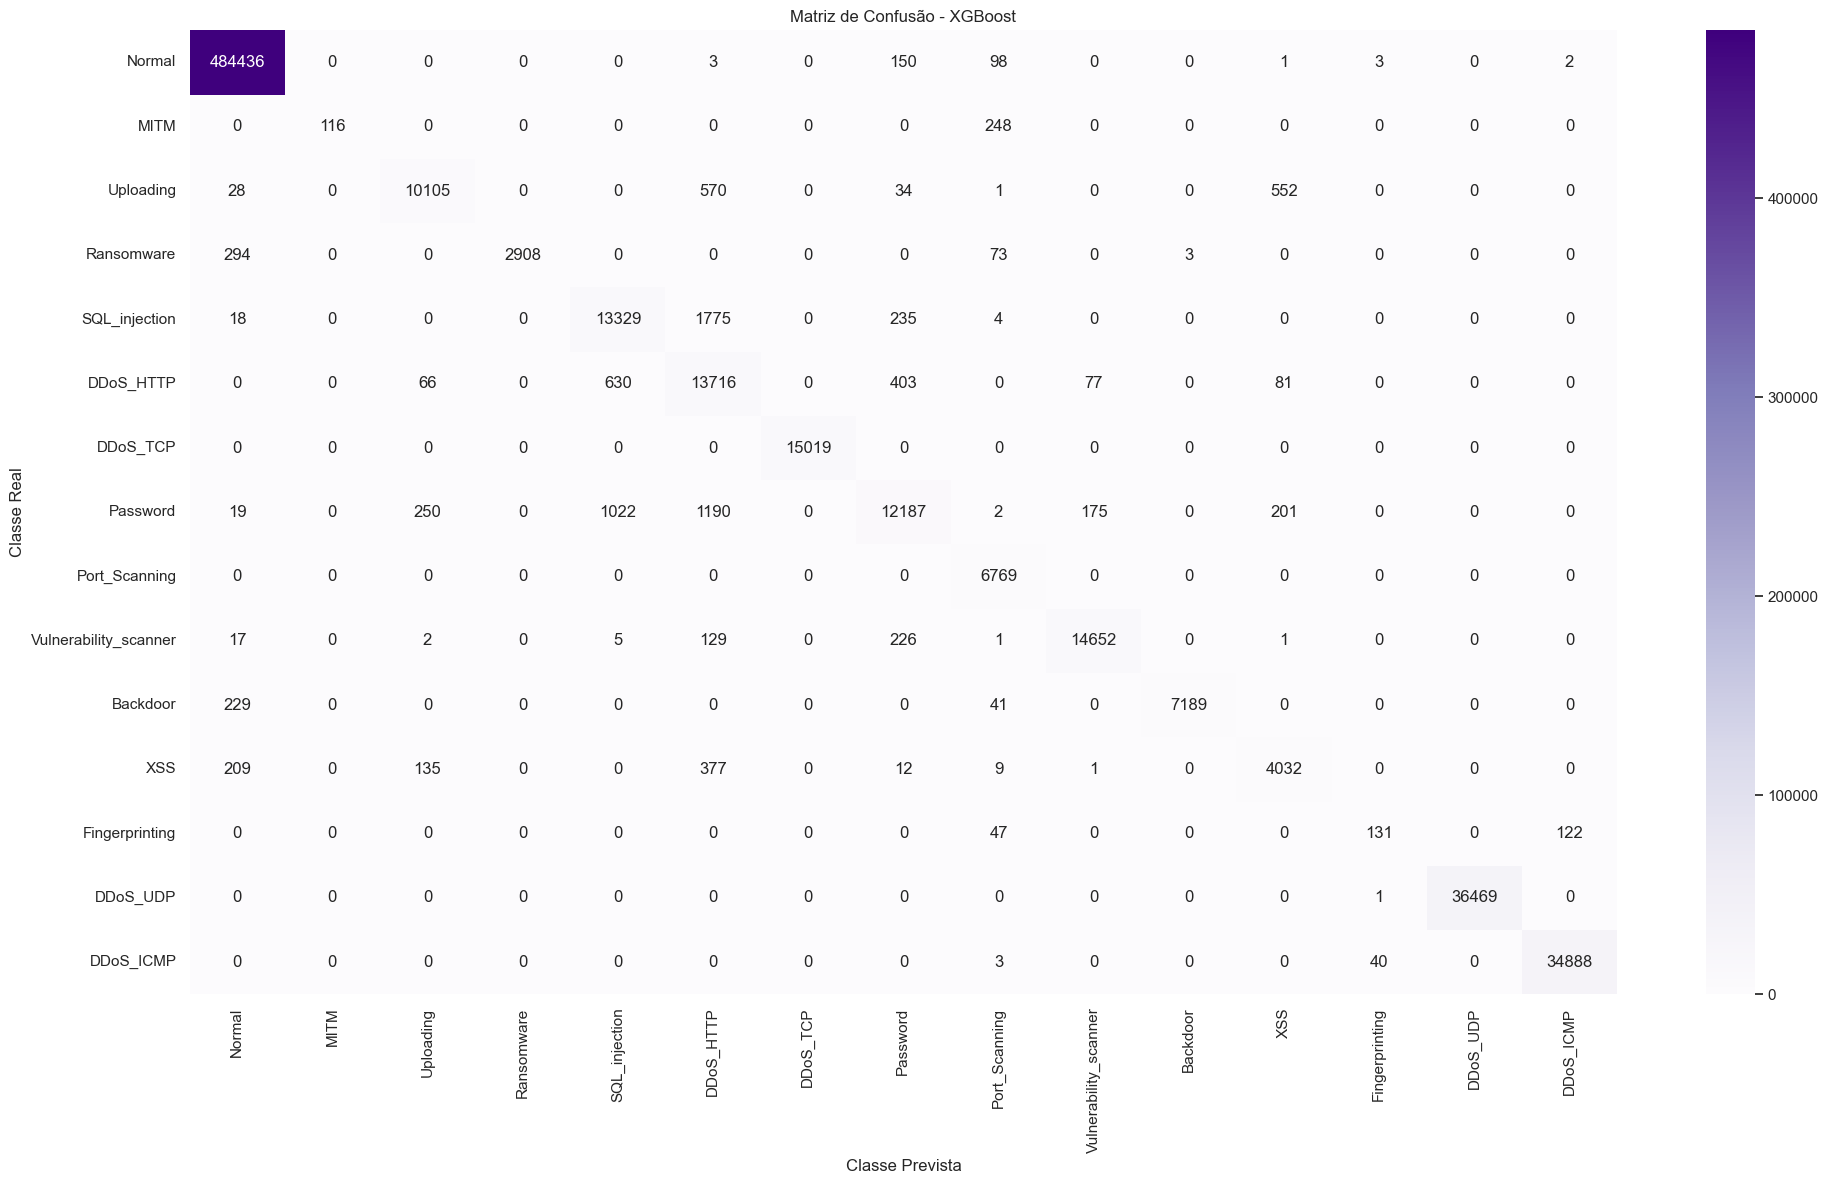

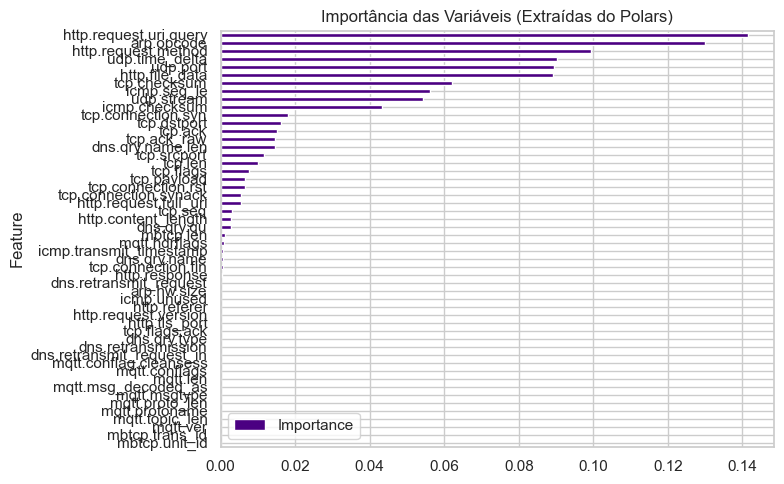

In [47]:


plt.figure(figsize=(20, 12))

sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=nome_das_classes,
    yticklabels=nome_das_classes,
)
plt.title("Matriz de Confusão - XGBoost")
plt.ylabel("Classe Real")
plt.xlabel("Classe Prevista")
plt.tight_layout()
plt.show()

# Importância das Features
plt.figure(figsize=(8, 5))
importances = modelo.feature_importances_
features = X_pl.columns

# Criando um gráfico de barras ordenado
pl.DataFrame({"Feature": features, "Importance": importances}).sort(
    "Importance", descending=True
).to_pandas().plot.barh(x="Feature", y="Importance", ax=plt.gca(), color="indigo")

plt.title("Importância das Variáveis (Extraídas do Polars)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Plotting bar graph with results from the algorithms 

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Definição dos Dados
data_lgb = [
    ["Normal", 1.00, 1.00, 1.00], ["Backdoor", 1.00, 0.94, 0.97], ["DDoS HTTP", 0.98, 0.97, 0.97],
    ["DDoS ICMP", 1.00, 1.00, 1.00], ["DDoS TCP", 1.00, 1.00, 1.00], ["DDoS UDP", 1.00, 1.00, 1.00],
    ["Fingerprinting", 0.30, 0.91, 0.45], ["MITM", 1.00, 1.00, 1.00], ["Password", 1.00, 1.00, 1.00],
    ["Port Scanning", 1.00, 0.91, 0.95], ["Ransomware", 0.88, 0.99, 0.93], ["SQL injection", 1.00, 1.00, 1.00],
    ["Uploading", 1.00, 1.00, 1.00], ["Vulnerability scanner", 1.00, 1.00, 1.00], ["XSS", 0.91, 0.92, 0.91]
]

data_xgb = [
    ["Normal", 1.00, 1.00, 1.00], ["Backdoor", 1.00, 0.96, 0.98], ["DDoS HTTP", 0.77, 0.92, 0.84],
    ["DDoS ICMP", 1.00, 1.00, 1.00], ["DDoS TCP", 1.00, 1.00, 1.00], ["DDoS UDP", 1.00, 1.00, 1.00],
    ["Fingerprinting", 0.75, 0.44, 0.55], ["MITM", 1.00, 0.32, 0.48], ["Password", 0.92, 0.81, 0.86],
    ["Port Scanning", 0.93, 1.00, 0.96], ["Ransomware", 1.00, 0.89, 0.94], ["SQL injection", 0.89, 0.87, 0.88],
    ["Uploading", 0.96, 0.90, 0.93], ["Vulnerability scanner", 0.98, 0.97, 0.98], ["XSS", 0.83, 0.84, 0.84]
]

columns = ["Classe", "Precisão", "Recall", "F1-Score"]

df_lgb = pd.DataFrame(data_lgb, columns=columns)
df_lgb["Algoritmo"] = "LightGBM"
df_xgb = pd.DataFrame(data_xgb, columns=columns)
df_xgb["Algoritmo"] = "XGBoost"
df_combined = pd.concat([df_lgb, df_xgb], ignore_index=True)

# 2. Configurações Globais
sns.set_theme(style="whitegrid")
metricas = ["Precisão", "Recall", "F1-Score"]
cores_modelos = {"LightGBM": "#00b4d8", "XGBoost": "#00bf63"}

# 3. Laço de Repetição para plotar, rotular e salvar cada gráfico
for metrica in metricas:
    plt.figure(figsize=(17, 7)) 
    
    ax = sns.barplot(
        data=df_combined,
        x="Classe", 
        y=metrica, 
        hue="Algoritmo", 
        palette=cores_modelos
    )
    

    for container in ax.containers:
        ax.bar_label(
            container, 
            fmt='%.2f',       # Define o formato do número (Duas casas decimais. Ex: 0.94)
            padding=4,        # Espaçamento em pontos entre o topo da barra e o texto
            fontsize=9,       # Tamanho da fonte do valor
            fontweight='bold',
            rotation=0        # Mantém os números na horizontal para facilitar leitura
        )
    
    # Customização estética
    plt.title(f"Comparativo de {metrica} por Classe e Algoritmo - LightGBM vs XGBoost", fontsize=14, fontweight='bold', pad=20)
    plt.ylabel(f"Valor", fontsize=12)
    plt.xlabel("Classe", fontsize=11, fontweight='bold', labelpad=12)
    
    # Ajustamos o limite superior para 1.20 para que o texto acima das barras de valor 1.00 não fique colado no teto
    plt.ylim(0, 1.20) 
    plt.legend(title="Algoritmo", loc="upper right")
    
    plt.xticks(rotation=45, ha="right", fontsize=10)
    plt.tight_layout()
    
    # Nome de arquivo limpo
    filename_clean = metrica.lower().replace("-", "_").replace("ã", "a")
    filename = f"comparative_{filename_clean}.png"
    
    plt.savefig(filename, dpi=300)
    print(f"Sucesso! O arquivo '{filename}' com valores nas barras foi gerado.")
    plt.close()

Sucesso! O arquivo 'comparative_precisao.png' com valores nas barras foi gerado.
Sucesso! O arquivo 'comparative_recall.png' com valores nas barras foi gerado.
Sucesso! O arquivo 'comparative_f1_score.png' com valores nas barras foi gerado.


### END!